# Personalized Handwriting Character Recognition

In [1]:
!nvidia-smi

Mon Apr 20 00:43:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:60:00.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## How this notebook is organized

Read from top to bottom. Each block below does one job:

1. **Imports** — load libraries; print Python and PyTorch version.
2. **Paths and seeds** — where data and checkpoints go; fix random seeds.
3. **Load EMNIST** — define preprocessing, create train/test datasets, show class names.
4. **Orientation figure** — show raw vs preprocessed pixels.
5. **Class counts** — print dataset sizes and per-class counts; plot train vs test class balance.
6. **`evaluate()`** — one function for loss, accuracy, and macro-F1 on any loader.
7. **Sanity check** — untrained model.
8. **Milestone 1 — Train baseline on EMNIST** — train/val split, short CNN loop, plots, save checkpoint.
9. **Milestone 2 — Collect personal handwriting** — instructions for the Tk app + a side-by-side preview against EMNIST.
10. **Milestone 3 — Baseline on personal test** — evaluate the EMNIST-trained model on your handwriting (no fine-tuning).
11. **Milestone 4 — Fine-tune on personal train** — freeze conv layers, retrain the head, save the fine-tuned checkpoint.
12. **Milestone 5 — Fine-tuned on personal test** — re-evaluate so we can compare against Milestone 3.
13. **Milestone 6 — Fine-tuned on EMNIST test** — sanity check that we did not catastrophically forget EMNIST.
14. **Results summary** — single comparison table across all four evaluations.
15. **Sample gallery** — extra visualizations.

## Imports

**What this section does:** import everything used later, and print environment facts (Python version, PyTorch version, whether CUDA is available).

In [2]:
import json
import random
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import EMNIST

# Make the repo root importable so we can pull TinyCNN, transforms, and the
# handwriting collection helpers from a single source of truth.
_REPO_ROOT = Path.cwd().resolve()
if _REPO_ROOT.name == "notebooks" or _REPO_ROOT.name == "final":
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from shared.model import TinyCNN, build_transfer_model, trainable_parameter_summary
from shared.transforms import emnist_transform, personal_transform

print("python", sys.version.split()[0])
print("torch", torch.__version__)
print("torch.cuda.is_available()", torch.cuda.is_available())
if torch.cuda.is_available():
    print("torch.cuda.get_device_name(0)", torch.cuda.get_device_name(0))

python 3.14.3
torch 2.10.0
torch.cuda.is_available() False


## Paths and seeds

**What this section does:** define folders (`data/` for EMNIST download, `artifacts/checkpoints/` for saved models) and call `set_seed()` so runs are a bit more repeatable.

In [3]:
# Project-relative paths (notebook lives in notebooks/)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "checkpoints"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Where EMNIST will download to
EMNIST_ROOT = str(DATA_ROOT)

SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("ARTIFACT_DIR =", ARTIFACT_DIR)

PROJECT_ROOT = /home/ad.msoe.edu/alliyum/CSC6621/final_project
DATA_ROOT    = /home/ad.msoe.edu/alliyum/CSC6621/final_project/data
ARTIFACT_DIR = /home/ad.msoe.edu/alliyum/CSC6621/final_project/artifacts/checkpoints


## Load EMNIST

**What this section does:** download (first run only) and load **EMNIST** with `split='byclass'`, attach the **same** `transform` to train and test, and print basic facts (`NUM_CLASSES`, a few class names, one tensor shape).

We use EMNIST with **`split='byclass'`** because it matches our goal of recognizing digits plus both uppercase and lowercase letters as distinct classes (62-way classification), which is what we need before adapting a generic model to a single writer’s handwriting. Among the official EMNIST splits, byclass preserves the fullest label granularity (separate cases) and reflects natural, writer-heavy variation in the public data, giving a realistic training set.

We read the **official class names and `class_to_idx` mapping from the dataset object** instead of hardcoding label order.

In [4]:
# EMNIST images are stored "sideways" in their raw bytes. The shared
# `emnist_transform` (imported above) applies ToTensor -> rotate(-90) -> hflip
# to bring them upright. We use the *same* transform for our personal
# handwriting because the collection app saves PNGs in EMNIST raw orientation
# (see `final/handwriting_app/image_io.py`).

train_ds_full = EMNIST(
    EMNIST_ROOT,
    split="byclass",
    train=True,
    download=True,
    transform=emnist_transform,
)
test_ds = EMNIST(
    EMNIST_ROOT,
    split="byclass",
    train=False,
    download=True,
    transform=emnist_transform,
)

NUM_CLASSES = len(train_ds_full.classes)
print("NUM_CLASSES =", NUM_CLASSES)
print("First few classes:", train_ds_full.classes[:10])
print("class_to_idx (sample):", {k: train_ds_full.class_to_idx[k] for k in list(train_ds_full.class_to_idx)[:5]})

x0, y0 = train_ds_full[0]
print("One sample tensor shape:", tuple(x0.shape), "label int:", int(y0), "label str:", train_ds_full.classes[int(y0)])

NUM_CLASSES = 62
First few classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
class_to_idx (sample): {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
One sample tensor shape: (1, 28, 28) label int: 35 label str: Z


### Quick visual check (orientation)

**What this section does:** show **six** examples. Top row: **raw** PIL images as stored in EMNIST. Bottom row: the **same** indices after `ToTensor`, `rotate(-90)`, and `hflip` (the preprocessing pipeline). This is only to verify that preprocessing looks reasonable.

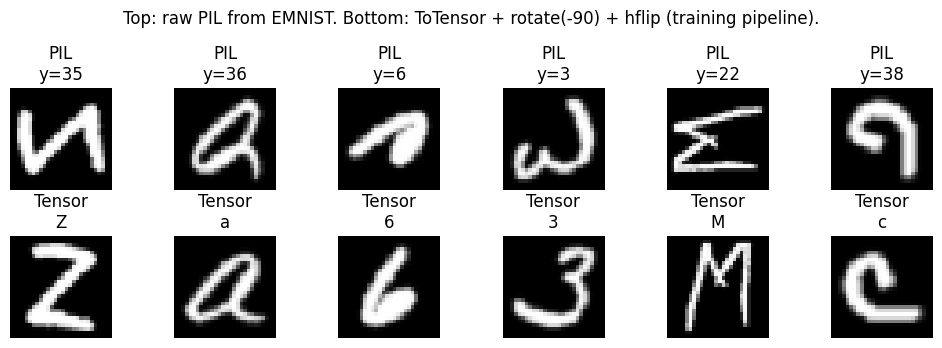

In [5]:
# Compare without vs with transforms on a few images (PIL before tensor pipeline).
raw_ds = EMNIST(EMNIST_ROOT, split="byclass", train=True, download=False, transform=None)

fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i in range(6):
    pil_img, y = raw_ds[i]
    axes[0, i].imshow(np.asarray(pil_img), cmap="gray")
    axes[0, i].set_title(f"PIL\ny={y}")
    axes[0, i].axis("off")

    xb, yb = train_ds_full[i]
    axes[1, i].imshow(xb.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Tensor\n{train_ds_full.classes[int(yb)]}")
    axes[1, i].axis("off")

plt.suptitle(
    "Top: raw PIL from EMNIST. Bottom: ToTensor + rotate(-90) + hflip (training pipeline)."
)
plt.tight_layout()
plt.show()

### Class distribution (train vs test)

**What this section does:** print how many images are in the **official** EMNIST train and test splits, then count images **per class** using the dataset’s `targets` field (the same integer labels used in training). **EMNIST `byclass` is not class-balanced** by design as some characters appear more often than others, so we report min/max counts and a simple ratio. A bar chart makes the imbalance easy to see.

In [6]:
# Counts come from torchvision's label list (same order as train_ds_full.classes).
train_targets = np.asarray(train_ds_full.targets, dtype=np.int64)
test_targets = np.asarray(test_ds.targets, dtype=np.int64)

n_train_total = len(train_ds_full)
n_test_total = len(test_ds)
print("EMNIST byclass — full splits")
print("  Training images:", n_train_total)
print("  Test images:    ", n_test_total)

EMNIST byclass — full splits
  Training images: 697932
  Test images:     116323


In [7]:
train_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
test_counts = np.bincount(test_targets, minlength=NUM_CLASSES)

print("Per-class image counts (train): min =", int(train_counts.min()), "max =", int(train_counts.max()))
print("Per-class image counts (test):  min =", int(test_counts.min()), "max =", int(test_counts.max()))

Per-class image counts (train): min = 1896 max = 38374
Per-class image counts (test):  min = 317 max = 6330


In [8]:
# Simple imbalance summary: ratio of most common class count to least common (within each split).
train_ratio = float(train_counts.max() / max(1, train_counts.min()))
test_ratio = float(test_counts.max() / max(1, test_counts.min()))
print("Train max/min class count ratio:", round(train_ratio, 2))
print("Test max/min class count ratio: ", round(test_ratio, 2))

Train max/min class count ratio: 20.24
Test max/min class count ratio:  19.97


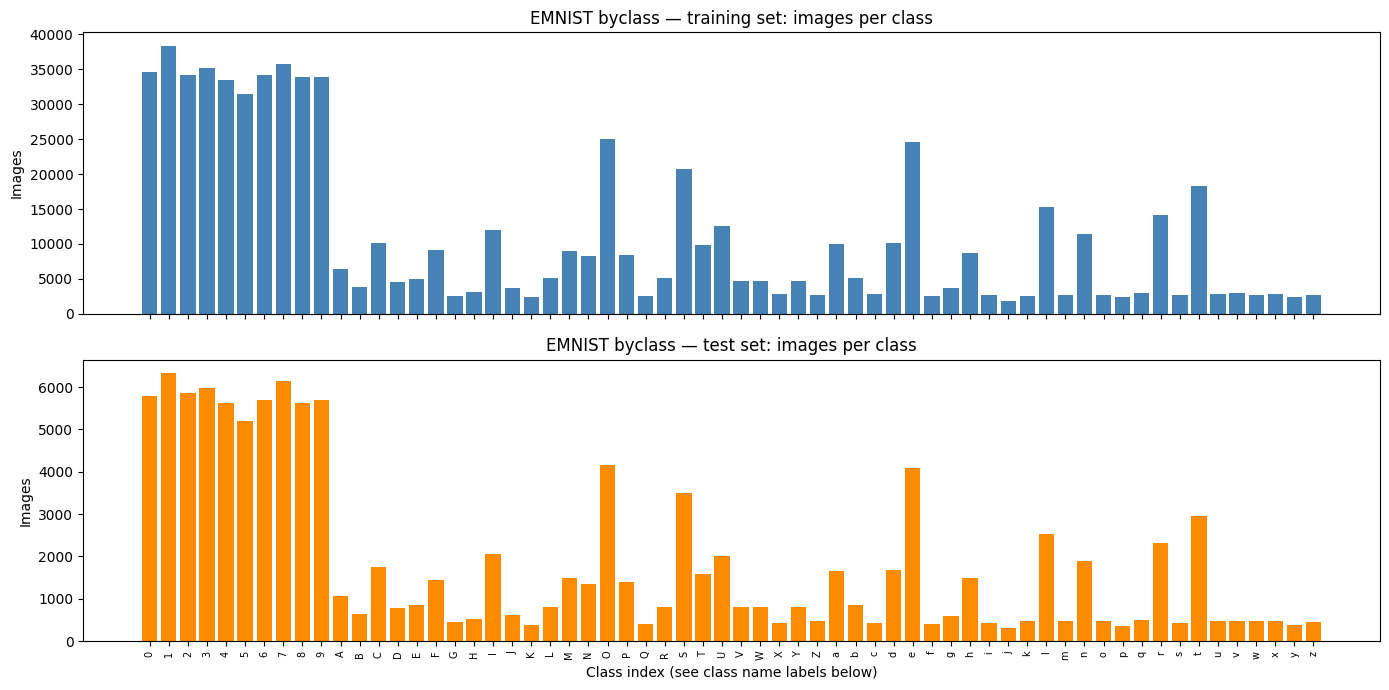

In [9]:
class_names = list(train_ds_full.classes)
x = np.arange(NUM_CLASSES)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(x, train_counts, color="steelblue")
axes[0].set_ylabel("Images")
axes[0].set_title("EMNIST byclass — training set: images per class")

axes[1].bar(x, test_counts, color="darkorange")
axes[1].set_ylabel("Images")
axes[1].set_xlabel("Class index (see class name labels below)")
axes[1].set_title("EMNIST byclass — test set: images per class")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

## Single `evaluate()` function

**What this section does:** define one **`evaluate()`** function used everywhere else. It runs the model on a `DataLoader`, averages loss, and computes **accuracy** and **macro F1** with scikit-learn.

In [10]:
def evaluate(model, data_loader, device, criterion, max_batches=None):
    # Returns average loss and accuracy on a loader (full pass unless max_batches is set).
    model.eval()
    losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(data_loader):
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            losses.append(float(loss.detach().cpu()))
            all_preds.append(logits.argmax(dim=1).detach().cpu())
            all_targets.append(yb.detach().cpu())

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()

    return {
        "loss": float(np.mean(losses)),
        "accuracy": float(accuracy_score(targets, preds)),
        "macro_f1": float(f1_score(targets, preds, average="macro", zero_division=0)),
    }

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

print("Using device:", device)

Using device: cpu


### Sanity check: random model on EMNIST test (first few batches)

**What this section does:** build the same small CNN with **random weights** and run `evaluate()` on only the **first 20 batches** of the test loader.

In [12]:
# `TinyCNN` is imported from `shared.model` at the top of the notebook so the
# same architecture can be reused by the transfer-learning cells below and by
# any standalone script. The architecture matches the original notebook
# definition exactly so older checkpoints still load.
print("TinyCNN imported from shared.model:", TinyCNN.__module__)
print("Trainable params for a fresh model:", trainable_parameter_summary(TinyCNN(62)))

In [13]:
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)

random_model = TinyCNN(NUM_CLASSES).to(device)
random_metrics = evaluate(random_model, test_loader, device, criterion, max_batches=20)

print("Random model (first 20 test batches):")
print(random_metrics)

Random model (first 20 test batches):
{'loss': 4.135556864738464, 'accuracy': 0.0115234375, 'macro_f1': 0.000369271596129533}


## Milestone 1 — Train the baseline CNN on EMNIST

**What this section does:** train the **TinyCNN** on EMNIST **training** images only, holding out a **validation** slice of that train split for per-epoch monitoring. The official **test** set is not used during the training loop (only once afterward for a fair baseline score). Then we save weights + JSON config and optionally score your own `data/personal/test` crops without fine-tuning.

### Why this baseline model?

We want a reasonable starting point, not a fully optimized system. A small **CNN** is standard for character images, and trains in reasonable time.

### Training loop

**What this cell does:** optionally subsample the official training split for speed, then randomly split those indices into train and validation portions. We run **Adam** + **cross-entropy** for `EPOCHS` epochs; after each epoch we call `evaluate()` on the **validation** loader only. The held-out **EMNIST test** set is reserved for the next cell. At the end we plot **loss and accuracy vs epoch** (train vs val) and **validation macro-F1** vs epoch.

In [14]:
USE_TRAIN_SUBSET = True
TRAIN_SUBSET_SIZE = 20_000  # only used if USE_TRAIN_SUBSET is True
VAL_FRACTION = 0.15  # fraction of the *pool* (below) held out as validation; rest is train-fit
BATCH_SIZE = 256
EPOCHS = 3
LR = 1e-3

rng = np.random.default_rng(SEED)

if USE_TRAIN_SUBSET:
    pool = rng.choice(len(train_ds_full), size=TRAIN_SUBSET_SIZE, replace=False).tolist()
    print(f"Pool from official train: {len(pool)} / {len(train_ds_full)} images")
else:
    pool = np.arange(len(train_ds_full), dtype=int).tolist()
    print(f"Pool = full official EMNIST train: {len(pool)} images")

rng.shuffle(pool)
n_pool = len(pool)
if n_pool < 2:
    raise ValueError("Need at least 2 images in the pool to form train and validation splits.")

Pool from official train: 20000 / 697932 images


In [15]:
n_val = max(1, int(round(n_pool * VAL_FRACTION)))
n_val = min(n_val, n_pool - 1)  # keep at least one image for training
val_idx = pool[:n_val]
train_fit_idx = pool[n_val:]

train_fit_ds = Subset(train_ds_full, train_fit_idx)
val_ds = Subset(train_ds_full, val_idx)
print("Train (fit) images:", len(train_fit_ds), "| Validation images:", len(val_ds))
print("Official EMNIST test images (not used during training loop):", len(test_ds))

Train (fit) images: 17000 | Validation images: 3000
Official EMNIST test images (not used during training loop): 116323


In [16]:
train_loader = DataLoader(train_fit_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=0)
test_loader_full = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=0)

model = TinyCNN(NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.detach().cpu()) * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += int((preds == yb).sum().detach().cpu())
        running_total += int(xb.size(0))

    train_metrics = {
        "epoch": epoch,
        "train_loss": running_loss / max(1, running_total),
        "train_acc": running_correct / max(1, running_total),
    }

    val_metrics = evaluate(model, val_loader, device, criterion)
    history["epoch"].append(epoch)
    history["train_loss"].append(train_metrics["train_loss"])
    history["train_acc"].append(train_metrics["train_acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    print(
        {
            **train_metrics,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
    )


{'epoch': 1, 'train_loss': 2.3529330895928777, 'train_acc': 0.42876470588235294, 'val_loss': 1.4080617030461628, 'val_acc': 0.6036666666666667, 'val_macro_f1': 0.335069728393287}
{'epoch': 2, 'train_loss': 1.1292683631672578, 'train_acc': 0.6727058823529412, 'val_loss': 0.980244110027949, 'val_acc': 0.7163333333333334, 'val_macro_f1': 0.5147229539003807}
{'epoch': 3, 'train_loss': 0.8555133822385003, 'train_acc': 0.7408823529411764, 'val_loss': 0.846040407816569, 'val_acc': 0.7493333333333333, 'val_macro_f1': 0.5576400091427909}


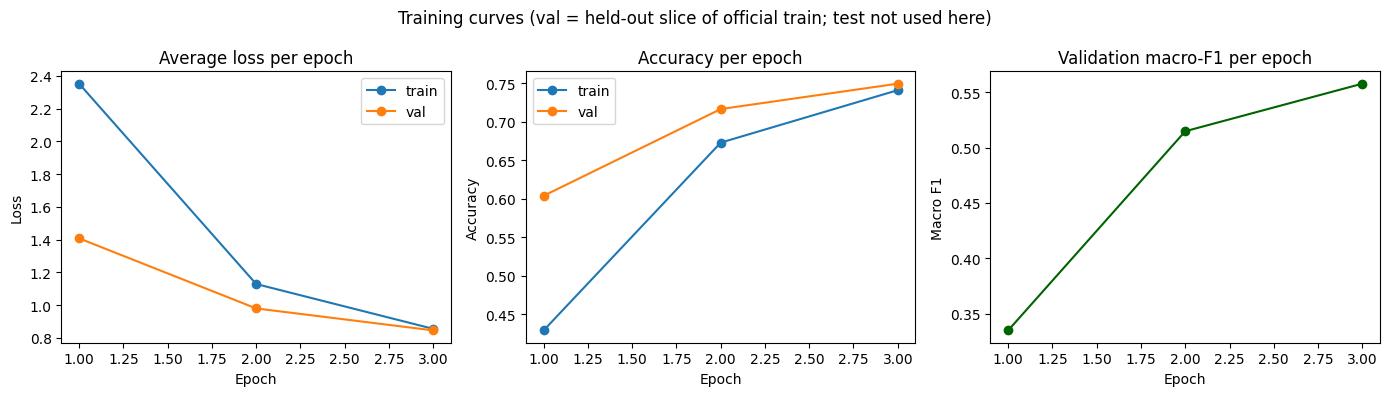

In [17]:
epochs = history["epoch"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Average loss per epoch")
axes[0].legend()
axes[0].grid(False)

axes[1].plot(epochs, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy per epoch")
axes[1].legend()
axes[1].grid(False)

axes[2].plot(epochs, history["val_macro_f1"], marker="o", color="darkgreen")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro F1")
axes[2].set_title("Validation macro-F1 per epoch")
axes[2].grid(False)

plt.suptitle("Training curves (val = held-out slice of official train; test not used here)")
plt.tight_layout()
plt.show()


### EMNIST test metrics (trained baseline)

**What this section does:** run `evaluate()` **once** on the **full** official EMNIST **test** loader using the **trained** weights.

In [18]:
final_test = evaluate(model, test_loader_full, device, criterion)
print("Final EMNIST test metrics:", final_test)

Final EMNIST test metrics: {'loss': 0.8320876712861814, 'accuracy': 0.7496109969653465, 'macro_f1': 0.5457033554086927}


### Save checkpoint + JSON config (Milestone 1 deliverable)

**What this section does:** save `state_dict` (weights only) and a small **JSON** file listing split, hyperparameters, subset flag, and UTC time. Together they document what was trained for demos and the final write-up.

In [19]:
checkpoint_path = ARTIFACT_DIR / "baseline_emnist_byclass.pt"
config_path = ARTIFACT_DIR / "baseline_emnist_byclass_config.json"

torch.save(model.state_dict(), checkpoint_path)

config = {
    "project": "handwriting_baseline",
    "emnist_split": "byclass",
    "num_classes": int(NUM_CLASSES),
    "seed": int(SEED),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "lr": float(LR),
    "use_train_subset": bool(USE_TRAIN_SUBSET),
    "train_subset_size": int(TRAIN_SUBSET_SIZE) if USE_TRAIN_SUBSET else None,
    "val_fraction_of_pool": float(VAL_FRACTION),
    "n_train_fit": int(len(train_fit_ds)),
    "n_val": int(len(val_ds)),
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "final_test_accuracy": float(final_test["accuracy"]),
    "final_test_macro_f1": float(final_test["macro_f1"]),
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Wrote:", checkpoint_path)
print("Wrote:", config_path)

## Milestone 2 — Collect personal handwriting

**What this section does:** explains how to use the handwriting collection app
to record your own samples in an EMNIST-compatible format, then previews a few
of the saved images side-by-side with EMNIST so we can confirm the orientation
and centering match before we evaluate the baseline on them.

### How to collect samples

From the **repo root** (the folder that contains `final/` and `shared/`), run:

```bash
python -m final.handwriting_app.collect --split train --per-class 10
python -m final.handwriting_app.collect --split test  --per-class 5
```

A small Tk window will pop up that asks you to draw each character (digits
first, then uppercase, then lowercase). Useful keyboard shortcuts:

| Key | Action |
|-----|--------|
| `Enter` | Save the current drawing and advance |
| `C`     | Clear the canvas |
| `Z`     | Undo the last stroke |
| `S`     | Skip the current class (do not save) |

Saved images live under:

```text
data/personal/<split>/<class_label>/<timestamp>_<class_label>.png
```

Where `<class_label>` matches the EMNIST `byclass` folder names: `0`–`9`,
`A`–`Z`, `a`–`z`. The app:

- Renders each pen stroke onto a 280×280 canvas, then crops to the inked
  bounding box, centers the glyph, and resizes to **28×28** with antialiasing.
- Reorients the result into EMNIST raw-byte orientation before saving, so the
  same `emnist_transform` (`ToTensor → rotate(-90) → hflip`) brings both EMNIST
  samples and your samples upright.
- Counts existing files per class so resuming a session is safe.

The cells below verify your collected data exists and previews a few images so
you can sanity-check orientation and centering against the EMNIST gallery.

In [20]:
from PIL import Image
from torch.utils.data import Dataset


class PersonalCharFolder(Dataset):
    """Per-class image folder for the handwriting we collect ourselves.

    Labels use the same integer indices as `train_ds_full.class_to_idx` so the
    62-way EMNIST classifier can be evaluated directly on these samples.
    """

    def __init__(self, root: Path, class_to_idx: dict, transform):
        self.transform = transform
        self.samples = []
        if not root.exists():
            return

        for cls_name, y in class_to_idx.items():
            folder = root / cls_name
            if not folder.is_dir():
                continue
            for pattern in ("*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"):
                for p in folder.glob(pattern):
                    self.samples.append((p, int(y)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, y = self.samples[i]
        img = Image.open(path).convert("L")
        if self.transform is not None:
            img = self.transform(img)
        return img, y


PERSONAL_ROOT = PROJECT_ROOT / "data" / "personal"
PERSONAL_TRAIN_DIR = PERSONAL_ROOT / "train"
PERSONAL_TEST_DIR = PERSONAL_ROOT / "test"


def _load_personal_split(split_dir: Path):
    if not split_dir.is_dir():
        return None
    ds = PersonalCharFolder(split_dir, train_ds_full.class_to_idx, personal_transform)
    return ds if len(ds) > 0 else None


personal_train_ds = _load_personal_split(PERSONAL_TRAIN_DIR)
personal_test_ds = _load_personal_split(PERSONAL_TEST_DIR)

print("Personal train dir:", PERSONAL_TRAIN_DIR, "| samples:", 0 if personal_train_ds is None else len(personal_train_ds))
print("Personal test dir: ", PERSONAL_TEST_DIR,  "| samples:", 0 if personal_test_ds  is None else len(personal_test_ds))

# Side-by-side preview: 6 EMNIST samples on top, up to 6 personal samples on bottom.
preview_source = personal_test_ds if personal_test_ds is not None else personal_train_ds
if preview_source is not None and len(preview_source) > 0:
    n_show = min(6, len(preview_source))
    fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
    for i in range(6):
        xb, yb = train_ds_full[i]
        axes[0, i].imshow(xb.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title(f"EMNIST: {train_ds_full.classes[int(yb)]}")
        axes[0, i].axis("off")
    for i in range(6):
        if i < n_show:
            xb, yb = preview_source[i]
            axes[1, i].imshow(xb.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
            axes[1, i].set_title(f"Yours: {train_ds_full.classes[int(yb)]}")
        axes[1, i].axis("off")
    plt.suptitle("Top: EMNIST samples. Bottom: your handwriting after the same transform.")
    plt.tight_layout()
    plt.show()
else:
    print("No personal samples found yet — run the collection app described above before continuing.")

PERSONAL_TEST_DIR does not exist yet: /home/ad.msoe.edu/alliyum/CSC6621/final_project/data/personal/test
Skipping personal test evaluation (pending Milestone 2 data collection).


## Milestone 3 — Baseline EMNIST model on personal handwriting

**What this section does:** evaluate the EMNIST-trained `TinyCNN` on the
personal **test** split *as-is* (no fine-tuning). This is the "how bad is the
generic model on my weird handwriting" baseline that Milestone 5 will improve
on. We report overall accuracy, macro-F1, and a per-class report so we can see
which characters confuse the model the most.

In [ ]:
baseline_personal_metrics = None
baseline_personal_report = None

if personal_test_ds is None:
    print("Skipping: no personal test data found at", PERSONAL_TEST_DIR)
else:
    personal_test_loader = DataLoader(personal_test_ds, batch_size=64, shuffle=False, num_workers=0)

    # `model` here is the EMNIST-trained baseline produced by Milestone 1.
    baseline_personal_metrics = evaluate(model, personal_test_loader, device, criterion)
    print("Baseline (EMNIST-trained) on personal test:")
    print(baseline_personal_metrics)

    # Per-class breakdown — only includes classes that actually appear in the test set.
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in personal_test_loader:
            xb = xb.to(device)
            logits = model(xb)
            all_preds.append(logits.argmax(dim=1).detach().cpu())
            all_targets.append(yb)
    preds_np = torch.cat(all_preds).numpy()
    targets_np = torch.cat(all_targets).numpy()
    present_labels = sorted(set(int(y) for y in targets_np))
    target_names = [train_ds_full.classes[i] for i in present_labels]
    baseline_personal_report = classification_report(
        targets_np,
        preds_np,
        labels=present_labels,
        target_names=target_names,
        digits=3,
        zero_division=0,
    )
    print("\nPer-class report (baseline on personal test):\n")
    print(baseline_personal_report)

## Milestone 4 — Fine-tune the baseline on personal handwriting

**What this section does:** reuses the EMNIST features the baseline already
learned, but adapts them to *your* handwriting. We:

1. Build a transfer model with `build_transfer_model(NUM_CLASSES, ...)`. This
   loads the saved EMNIST checkpoint, **freezes the two convolutional layers**
   so the early features stay general, and **re-initializes the final
   classifier head** so it can move quickly toward your writing style.
2. Hold out a small validation slice from the personal **train** split for
   per-epoch monitoring.
3. Train for a handful of epochs with a small learning rate (the conv weights
   are frozen, so only the dense layers are updating; we want gentle steps so
   the head doesn't oscillate on a tiny dataset).
4. Save the fine-tuned weights to
   `artifacts/checkpoints/finetuned_personal.pt`.

In [ ]:
FT_EPOCHS = 15
FT_LR = 1e-3
FT_BATCH_SIZE = 32
FT_VAL_FRACTION = 0.15

finetuned_model = None
ft_history = None
ft_checkpoint_path = ARTIFACT_DIR / "finetuned_personal.pt"

if personal_train_ds is None:
    print("Skipping fine-tune: no personal train data at", PERSONAL_TRAIN_DIR)
elif not (ARTIFACT_DIR / "baseline_emnist_byclass.pt").is_file():
    print("Skipping fine-tune: baseline checkpoint not found. Run Milestone 1 first.")
else:
    set_seed(SEED)

    n_personal = len(personal_train_ds)
    n_val_p = max(1, int(round(n_personal * FT_VAL_FRACTION)))
    n_val_p = min(n_val_p, n_personal - 1)
    perm = np.random.default_rng(SEED).permutation(n_personal).tolist()
    val_idx_p = perm[:n_val_p]
    train_idx_p = perm[n_val_p:]
    ft_train_ds = Subset(personal_train_ds, train_idx_p)
    ft_val_ds = Subset(personal_train_ds, val_idx_p)
    print(f"Personal fine-tune split — train: {len(ft_train_ds)}  val: {len(ft_val_ds)}")

    finetuned_model = build_transfer_model(
        num_classes=NUM_CLASSES,
        checkpoint_path=ARTIFACT_DIR / "baseline_emnist_byclass.pt",
        freeze_conv=True,
        reset_head=True,
        device=device,
    )
    print("Trainable params after freezing conv layers:", trainable_parameter_summary(finetuned_model))

    ft_train_loader = DataLoader(ft_train_ds, batch_size=FT_BATCH_SIZE, shuffle=True, num_workers=0)
    ft_val_loader = DataLoader(ft_val_ds, batch_size=64, shuffle=False, num_workers=0)

    ft_optimizer = torch.optim.Adam(
        [p for p in finetuned_model.parameters() if p.requires_grad],
        lr=FT_LR,
    )

    ft_history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

    for epoch in range(1, FT_EPOCHS + 1):
        finetuned_model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for xb, yb in ft_train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            ft_optimizer.zero_grad()
            logits = finetuned_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            ft_optimizer.step()

            running_loss += float(loss.detach().cpu()) * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += int((preds == yb).sum().detach().cpu())
            running_total += int(xb.size(0))

        train_loss = running_loss / max(1, running_total)
        train_acc = running_correct / max(1, running_total)
        val_metrics = evaluate(finetuned_model, ft_val_loader, device, criterion)

        ft_history["epoch"].append(epoch)
        ft_history["train_loss"].append(train_loss)
        ft_history["train_acc"].append(train_acc)
        ft_history["val_loss"].append(val_metrics["loss"])
        ft_history["val_acc"].append(val_metrics["accuracy"])
        ft_history["val_macro_f1"].append(val_metrics["macro_f1"])

        print({
            "epoch": epoch,
            "train_loss": round(train_loss, 4),
            "train_acc": round(train_acc, 4),
            "val_loss": round(val_metrics["loss"], 4),
            "val_acc": round(val_metrics["accuracy"], 4),
            "val_macro_f1": round(val_metrics["macro_f1"], 4),
        })

    torch.save(finetuned_model.state_dict(), ft_checkpoint_path)
    print("Wrote:", ft_checkpoint_path)

In [ ]:
if ft_history is not None and len(ft_history["epoch"]) > 0:
    epochs_ft = ft_history["epoch"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(epochs_ft, ft_history["train_loss"], marker="o", label="train")
    axes[0].plot(epochs_ft, ft_history["val_loss"], marker="o", label="val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Fine-tune loss per epoch")
    axes[0].legend()

    axes[1].plot(epochs_ft, ft_history["train_acc"], marker="o", label="train")
    axes[1].plot(epochs_ft, ft_history["val_acc"], marker="o", label="val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Fine-tune accuracy per epoch")
    axes[1].legend()

    axes[2].plot(epochs_ft, ft_history["val_macro_f1"], marker="o", color="darkgreen")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro F1")
    axes[2].set_title("Validation macro-F1 per epoch")

    plt.suptitle("Fine-tuning the classifier head on personal handwriting (conv layers frozen)")
    plt.tight_layout()
    plt.show()
else:
    print("No fine-tune history to plot.")

## Milestone 5 — Fine-tuned model on personal handwriting

**What this section does:** evaluates the *fine-tuned* model on the same
personal **test** split that Milestone 3 used. Comparing these numbers head-to-
head with Milestone 3 tells us whether transfer learning actually helped on
your handwriting.

In [ ]:
finetuned_personal_metrics = None
finetuned_personal_report = None

if finetuned_model is None:
    print("Skipping: no fine-tuned model available.")
elif personal_test_ds is None:
    print("Skipping: no personal test data at", PERSONAL_TEST_DIR)
else:
    personal_test_loader = DataLoader(personal_test_ds, batch_size=64, shuffle=False, num_workers=0)
    finetuned_personal_metrics = evaluate(finetuned_model, personal_test_loader, device, criterion)
    print("Fine-tuned model on personal test:")
    print(finetuned_personal_metrics)

    finetuned_model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in personal_test_loader:
            xb = xb.to(device)
            logits = finetuned_model(xb)
            all_preds.append(logits.argmax(dim=1).detach().cpu())
            all_targets.append(yb)
    preds_np = torch.cat(all_preds).numpy()
    targets_np = torch.cat(all_targets).numpy()
    present_labels = sorted(set(int(y) for y in targets_np))
    target_names = [train_ds_full.classes[i] for i in present_labels]
    finetuned_personal_report = classification_report(
        targets_np,
        preds_np,
        labels=present_labels,
        target_names=target_names,
        digits=3,
        zero_division=0,
    )
    print("\nPer-class report (fine-tuned on personal test):\n")
    print(finetuned_personal_report)

## Milestone 6 — Sanity check: fine-tuned model on EMNIST test

**What this section does:** runs the fine-tuned model against the *EMNIST*
test set so we can see how much general performance we traded away while
adapting the head to your handwriting. Since the convolutional features were
frozen during fine-tuning, the drop should be modest — large drops would be a
red flag for catastrophic forgetting.

In [ ]:
finetuned_emnist_metrics = None
if finetuned_model is None:
    print("Skipping: no fine-tuned model available.")
else:
    finetuned_emnist_metrics = evaluate(finetuned_model, test_loader_full, device, criterion)
    print("Fine-tuned model on EMNIST test:", finetuned_emnist_metrics)
    print("Baseline (for reference):       ", final_test)

## Results summary

The cell below collects every metric we computed across the three experiments
into one table:

- **Baseline on EMNIST test** — what the off-the-shelf CNN scores on the data
  it was trained on (Milestone 1).
- **Baseline on personal test** — that same model, no retraining, on your
  handwriting (Milestone 3).
- **Fine-tuned on personal test** — the transfer-learned model on your
  handwriting (Milestone 5).
- **Fine-tuned on EMNIST test** — the transfer-learned model still scored on
  EMNIST as a sanity check (Milestone 6).

The interesting comparison is rows two and three: how much did fine-tuning
move accuracy and macro-F1 on *your* handwriting?

In [ ]:
def _row(name, metrics):
    if metrics is None:
        return (name, "n/a", "n/a", "n/a")
    return (
        name,
        f"{metrics['loss']:.4f}",
        f"{metrics['accuracy']:.4f}",
        f"{metrics['macro_f1']:.4f}",
    )


rows = [
    _row("Baseline on EMNIST test",        final_test),
    _row("Baseline on personal test",      baseline_personal_metrics),
    _row("Fine-tuned on personal test",    finetuned_personal_metrics),
    _row("Fine-tuned on EMNIST test",      finetuned_emnist_metrics),
]

col_widths = [max(len(str(r[i])) for r in rows + [("Experiment", "Loss", "Accuracy", "Macro-F1")]) for i in range(4)]
header = ("Experiment", "Loss", "Accuracy", "Macro-F1")

def _fmt_row(r):
    return "  ".join(str(c).ljust(col_widths[i]) for i, c in enumerate(r))

print(_fmt_row(header))
print("-" * (sum(col_widths) + 2 * (len(col_widths) - 1)))
for r in rows:
    print(_fmt_row(r))

if baseline_personal_metrics is not None and finetuned_personal_metrics is not None:
    delta_acc = finetuned_personal_metrics["accuracy"] - baseline_personal_metrics["accuracy"]
    delta_f1 = finetuned_personal_metrics["macro_f1"] - baseline_personal_metrics["macro_f1"]
    print(f"\nDelta on personal test — accuracy: {delta_acc:+.4f}, macro-F1: {delta_f1:+.4f}")

## Gallery — a few examples after preprocessing

**What this section does:** show **12** random early training examples after the full tensor pipeline, with class names in the title. Useful for slides or the report.

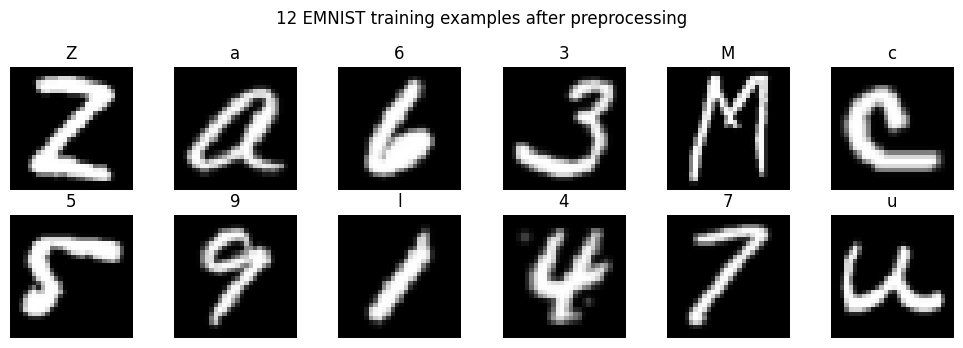

In [21]:
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i in range(12):
    r, c = divmod(i, 6)
    xb, yb = train_ds_full[i]
    axes[r, c].imshow(xb.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[r, c].set_title(train_ds_full.classes[int(yb)])
    axes[r, c].axis("off")

plt.suptitle("12 EMNIST training examples after preprocessing")
plt.tight_layout()
plt.show()

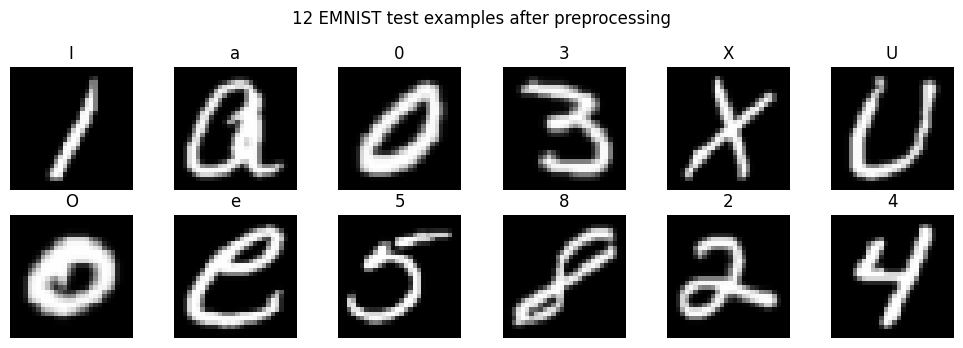

In [22]:
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i in range(12):
    r, c = divmod(i, 6)
    xb, yb = test_ds[i]
    axes[r, c].imshow(xb.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[r, c].set_title(train_ds_full.classes[int(yb)])
    axes[r, c].axis("off")

plt.suptitle("12 EMNIST test examples after preprocessing")
plt.tight_layout()
plt.show()